# Hungarian Election Polling Analysis & Estimation

Aggregating polls from multiple Hungarian pollsters to produce election estimates with uncertainty intervals.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from scipy.optimize import minimize

plt.rcParams.update({
    'figure.figsize': (14, 7),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

## 1. Load & Clean Data

In [24]:
df = pd.read_csv('data.csv', sep='\t', encoding='utf-8')

df.columns = [
    'start_date', 'end_date', 'pollster', 'method', 'sample_size',
    'Fidesz', 'TISZA', 'Bal', 'MiHazank', 'MKKP', 'EM',
    'week_code', 'FideszV', 'TiszaV', 'DKV', 'MiHazankV', 'MKKPV', 'EMV'
]

for col in ['start_date', 'end_date']:
    df[col] = pd.to_datetime(df[col], format='%Y.%m.%d', errors='coerce')

df['mid_date'] = df['start_date'] + (df['end_date'] - df['start_date']) / 2
df['mid_date'] = df['mid_date'].fillna(df['end_date'])

for col in ['Fidesz', 'TISZA', 'Bal', 'MiHazank', 'MKKP', 'EM', 'sample_size']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values('mid_date').reset_index(drop=True)

print(f"Polls loaded: {len(df)}")
print(f"Date range: {df['mid_date'].min():%Y-%m-%d} to {df['mid_date'].max():%Y-%m-%d}")
print(f"Pollsters: {df['pollster'].nunique()} — {', '.join(df['pollster'].dropna().unique())}")
print(f"\nMethods: {df['method'].value_counts().to_dict()}")
df.tail(10)

Polls loaded: 201
Date range: 2021-06-05 to 2026-03-03
Pollsters: 7 — Medián, Nézőpont, Závecz, IDEA, Publicus, Republikon, 21 Kutató

Methods: {'Telefonos': 115, 'Online': 52, 'Személyes': 22, 'Hibrid': 12}


,start_date,end_date,pollster,method,sample_size,Fidesz,TISZA,Bal,MiHazank,MKKP,EM,week_code,FideszV,TiszaV,DKV,MiHazankV,MKKPV,EMV,mid_date
191,2026-01-21,2026-01-24,Publicus,Telefonos,1001,40.0,48.0,4.0,5.0,3.0,NaN,259,39.4693,48.3963,3.2333,5.1165,3.1556,NaN,2026-01-22 12:00:00
192,2026-01-28,2026-02-02,21 Kutató,Hibrid,1000,37.0,53.0,3.0,5.0,2.0,NaN,261,39.6567,48.3963,3.2333,5.1165,3.1556,NaN,2026-01-30 12:00:00
193,2026-01-31,2026-02-06,IDEA,Online,1500,38.0,48.0,5.0,5.0,3.0,NaN,261,39.6567,48.3963,3.2333,5.2436,3.1556,NaN,2026-02-03 00:00:00
194,2026-02-09,2026-02-11,Nézőpont,Telefonos,1000,46.0,40.0,4.0,7.0,3.0,NaN,262,39.5125,48.3963,3.3775,5.3878,3.0114,NaN,2026-02-10 00:00:00
195,2026-02-09,2026-02-12,Publicus,Telefonos,1000,39.0,48.0,5.0,5.0,4.0,NaN,262,39.4081,48.3963,3.4819,5.3878,3.1158,NaN,2026-02-10 12:00:00
196,2026-02-12,2026-02-17,Republikon,Telefonos,1000,39.0,47.0,3.0,6.0,5.0,NaN,263,39.5075,48.3963,3.3825,5.3878,3.1158,NaN,2026-02-14 12:00:00
197,2026-02-18,2026-02-23,Medián,Telefonos,1000,35.0,55.0,2.0,6.0,2.0,NaN,264,38.7579,49.1459,3.5699,5.5752,2.9284,NaN,2026-02-20 12:00:00
198,2026-02-23,2026-02-25,Nézőpont,Telefonos,1000,45.0,40.0,3.0,8.0,4.0,NaN,264,38.6137,49.1459,3.4257,5.7194,3.0726,NaN,2026-02-24 00:00:00
199,2026-02-22,2026-02-28,Závecz,Hibrid,1000,38.0,50.0,3.0,7.0,2.0,NaN,264,38.4636,49.2960,3.2756,6.0196,2.9225,NaN,2026-02-25 00:00:00
200,NaT,2026-03-03,Publicus,Telefonos,1000,39.0,47.0,4.0,6.0,4.0,NaN,265,38.4636,49.1916,3.1712,6.1240,2.9225,NaN,2026-03-03 00:00:00


## 2. Polling Trends Over Time

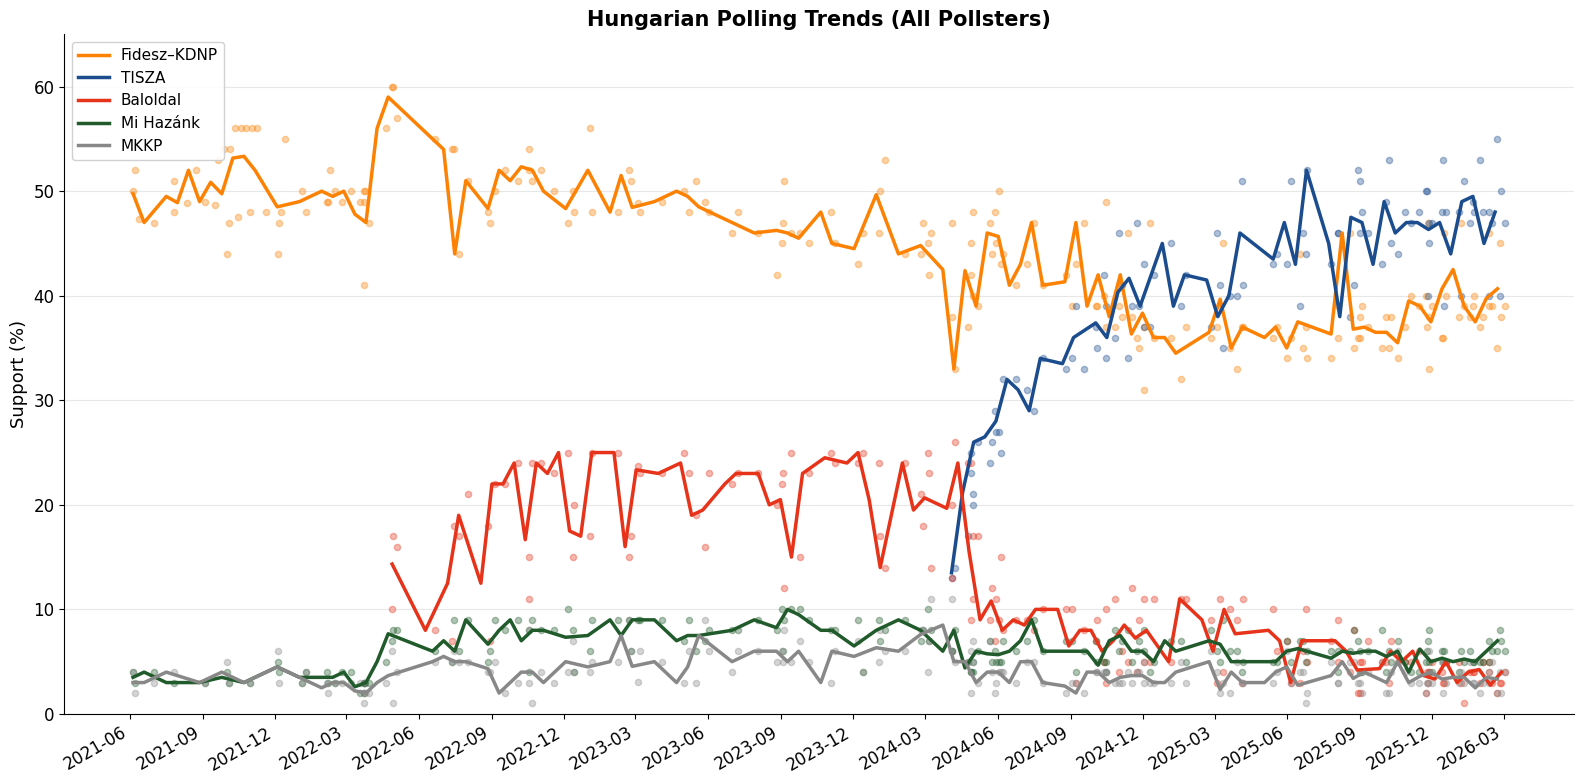

In [25]:
PARTY_COLORS = {
    'Fidesz': '#fd8204',
    'TISZA': '#1B4D8E',
    'Bal': '#e6331a',
    'MiHazank': '#215b2c',
    'MKKP': '#888888',
    'EM': '#7b2d8e',
}

PARTY_LABELS = {
    'Fidesz': 'Fidesz–KDNP',
    'TISZA': 'TISZA',
    'Bal': 'Baloldal',
    'MiHazank': 'Mi Hazánk',
    'MKKP': 'MKKP',
    'EM': 'Egys. Magyarországért',
}

parties = ['Fidesz', 'TISZA', 'Bal', 'MiHazank', 'MKKP']

fig, ax = plt.subplots(figsize=(16, 8))

for party in parties:
    mask = df[party].notna()
    ax.scatter(
        df.loc[mask, 'mid_date'], df.loc[mask, party],
        color=PARTY_COLORS[party], alpha=0.35, s=20, zorder=2
    )
    rolling = df.loc[mask, ['mid_date', party]].set_index('mid_date').resample('14D').mean()
    rolling = rolling[party].interpolate()
    ax.plot(
        rolling.index, rolling.values,
        color=PARTY_COLORS[party], linewidth=2.5, label=PARTY_LABELS[party], zorder=3
    )

ax.set_ylabel('Support (%)', fontsize=13)
ax.set_xlabel('')
ax.set_title('Hungarian Polling Trends (All Pollsters)', fontsize=15, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 65)
plt.tight_layout()
plt.show()

## 3. Pollster House Effects

Different pollsters have systematic biases. We estimate house effects as each pollster's average deviation from the overall trend.

In [26]:
recent = df[df['mid_date'] >= '2024-06-01'].copy()

overall_means = recent[parties].mean()

house_effects = pd.DataFrame(index=recent['pollster'].unique(), columns=parties, dtype=float)
pollster_counts = {}

for pollster in recent['pollster'].unique():
    pmask = recent['pollster'] == pollster
    pollster_counts[pollster] = pmask.sum()
    for party in parties:
        vals = recent.loc[pmask, party].dropna()
        if len(vals) >= 2:
            house_effects.loc[pollster, party] = vals.mean() - overall_means[party]

house_effects = house_effects.dropna(how='all')

print("Pollster house effects (deviation from mean, since 2024-06):")
print("Positive = pollster overestimates that party vs. average\n")

styled = house_effects.round(1).copy()
styled['N polls'] = [pollster_counts.get(p, 0) for p in styled.index]
styled

Pollster house effects (deviation from mean, since 2024-06):
Positive = pollster overestimates that party vs. average



,Fidesz,TISZA,Bal,MiHazank,MKKP,N polls
Medián,0.7,2.1,-2.2,-0.5,-0.3,11
Publicus,-0.8,0.3,2.7,-0.8,-0.4,17
21 Kutató,-1.6,5.9,-2.0,-0.2,-0.8,9
IDEA,-0.3,0.1,0.2,-0.5,-0.5,15
Nézőpont,7.4,-6.0,-1.7,0.9,0.2,13
Závecz,-1.5,0.5,0.5,0.1,-0.2,10
Republikon,-4.1,-0.6,1.0,1.2,1.6,14


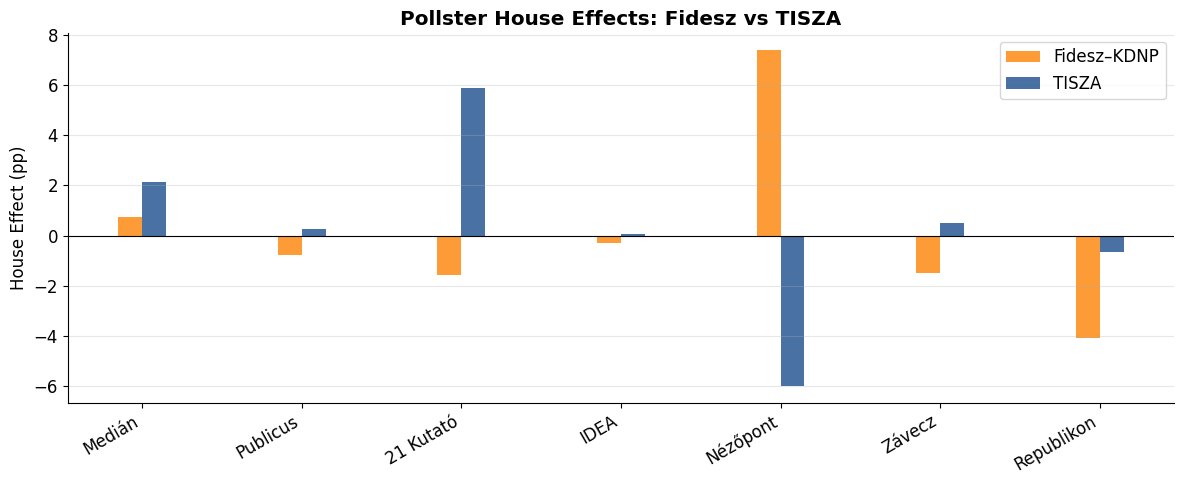

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(house_effects.index))
width = 0.15

for i, party in enumerate(['Fidesz', 'TISZA']):
    vals = house_effects[party].astype(float).values
    ax.bar(x + i * width, vals, width, label=PARTY_LABELS[party],
           color=PARTY_COLORS[party], alpha=0.8)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(house_effects.index, rotation=30, ha='right')
ax.set_ylabel('House Effect (pp)')
ax.set_title('Pollster House Effects: Fidesz vs TISZA', fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Election Estimate Model

We build a weighted polling average where:
- **Recency weight**: exponential decay — recent polls count more (half-life = 14 days)
- **Sample size weight**: larger samples get more weight (sqrt scaling)
- **House-effect correction**: subtract estimated pollster bias
- **Uncertainty**: bootstrapped confidence intervals

In [28]:
def weighted_poll_average(df_polls, parties, as_of_date=None, halflife_days=14, house_effects=None):
    """Compute house-effect-corrected, recency-weighted polling average."""
    if as_of_date is None:
        as_of_date = df_polls['mid_date'].max()
    as_of_date = pd.Timestamp(as_of_date)

    work = df_polls[df_polls['mid_date'] <= as_of_date].copy()
    work = work[work['mid_date'] >= as_of_date - timedelta(days=90)]

    if len(work) == 0:
        return {p: np.nan for p in parties}

    days_ago = (as_of_date - work['mid_date']).dt.total_seconds() / 86400
    recency_w = np.exp(-np.log(2) * days_ago / halflife_days)
    sample_w = np.sqrt(work['sample_size'].fillna(1000) / 1000)
    weights = recency_w * sample_w

    results = {}
    for party in parties:
        vals = work[party].copy()
        if house_effects is not None:
            for pollster in work['pollster'].unique():
                if pollster in house_effects.index and pd.notna(house_effects.loc[pollster, party]):
                    pmask = work['pollster'] == pollster
                    vals.loc[pmask] = vals.loc[pmask] - house_effects.loc[pollster, party]

        valid = vals.notna()
        if valid.sum() == 0:
            results[party] = np.nan
            continue

        w = weights[valid]
        v = vals[valid]
        results[party] = np.average(v, weights=w)

    return results


def bootstrap_estimate(df_polls, parties, as_of_date=None, halflife_days=14,
                       house_effects=None, n_boot=2000):
    """Bootstrap confidence intervals for the polling average."""
    if as_of_date is None:
        as_of_date = df_polls['mid_date'].max()
    as_of_date = pd.Timestamp(as_of_date)

    work = df_polls[df_polls['mid_date'] <= as_of_date].copy()
    work = work[work['mid_date'] >= as_of_date - timedelta(days=90)]

    if len(work) < 3:
        point = weighted_poll_average(df_polls, parties, as_of_date, halflife_days, house_effects)
        return {p: (point[p], point[p], point[p]) for p in parties}

    boot_results = {p: [] for p in parties}
    rng = np.random.default_rng(42)

    for _ in range(n_boot):
        idx = rng.choice(len(work), size=len(work), replace=True)
        sample = work.iloc[idx]
        est = weighted_poll_average(sample, parties, as_of_date, halflife_days, house_effects)
        for p in parties:
            boot_results[p].append(est[p])

    results = {}
    for p in parties:
        arr = np.array([x for x in boot_results[p] if not np.isnan(x)])
        if len(arr) == 0:
            results[p] = (np.nan, np.nan, np.nan)
        else:
            results[p] = (np.percentile(arr, 5), np.median(arr), np.percentile(arr, 95))

    return results

In [29]:
current_estimate = bootstrap_estimate(df, parties, house_effects=house_effects)

print("=" * 60)
print("  CURRENT ELECTION ESTIMATE  ")
print(f"  As of: {df['mid_date'].max():%Y-%m-%d}")
print("=" * 60)
print(f"{'Party':<20} {'Estimate':>10} {'90% CI':>18}")
print("-" * 50)

for party in parties:
    lo, med, hi = current_estimate[party]
    if np.isnan(med):
        continue
    print(f"{PARTY_LABELS[party]:<20} {med:>9.1f}%  [{lo:>5.1f}% – {hi:>5.1f}%]")

print("=" * 60)

  CURRENT ELECTION ESTIMATE  
  As of: 2026-03-03
Party                  Estimate             90% CI
--------------------------------------------------
Fidesz–KDNP               39.0%  [ 37.8% –  40.1%]
TISZA                     47.9%  [ 46.9% –  49.2%]
Baloldal                   3.3%  [  2.5% –   4.1%]
Mi Hazánk                  6.2%  [  5.7% –   6.5%]
MKKP                       3.3%  [  2.9% –   3.8%]


## 5. Trend Line — Rolling Estimates Over Time

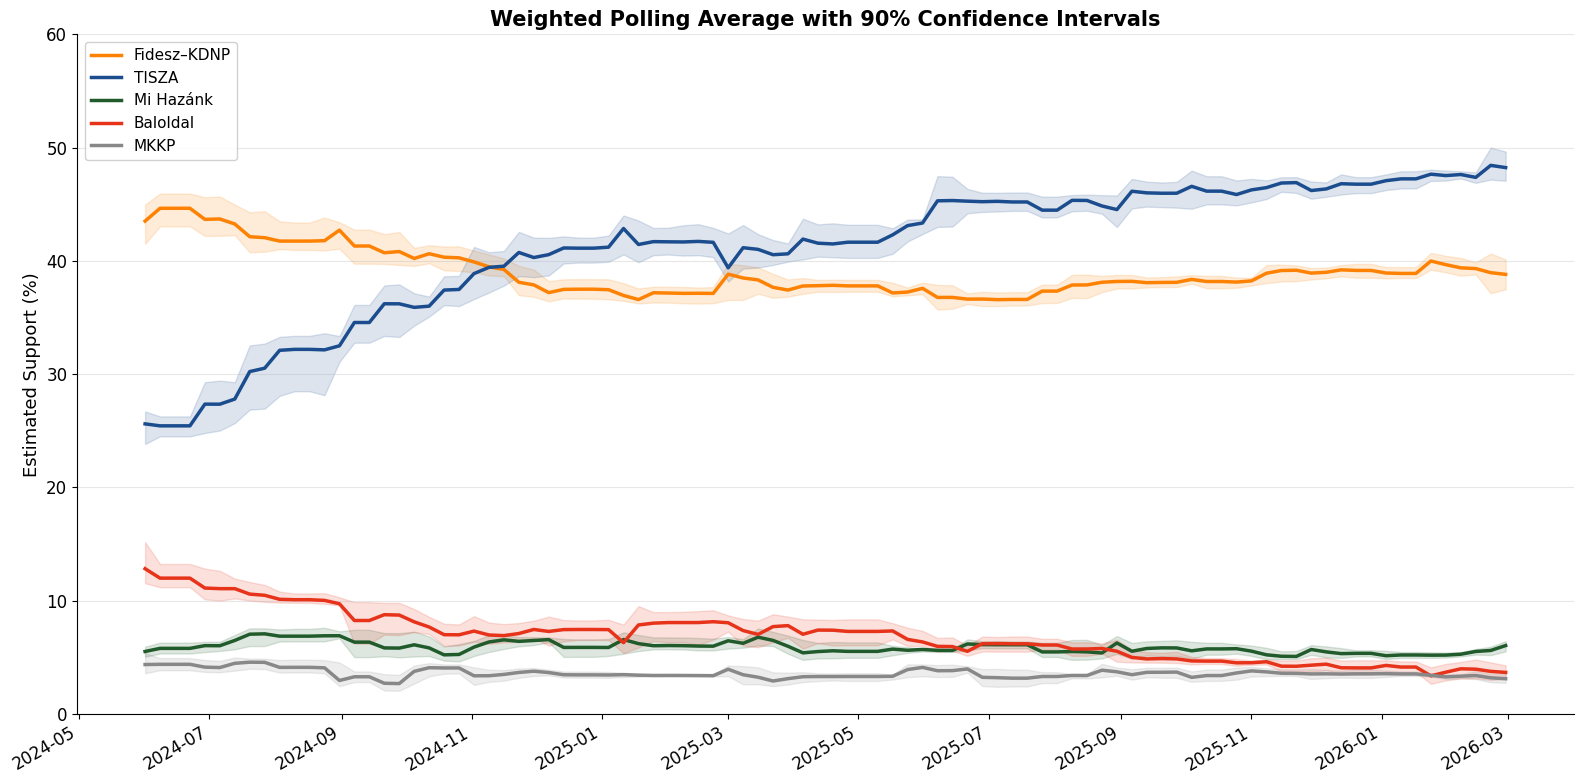

In [30]:
date_range = pd.date_range(
    start=max(df['mid_date'].min(), pd.Timestamp('2024-06-01')),
    end=df['mid_date'].max(),
    freq='7D'
)

trend_data = {p: {'dates': [], 'lo': [], 'med': [], 'hi': []} for p in parties}

for d in date_range:
    est = bootstrap_estimate(df, parties, as_of_date=d, house_effects=house_effects, n_boot=500)
    for p in parties:
        lo, med, hi = est[p]
        if not np.isnan(med):
            trend_data[p]['dates'].append(d)
            trend_data[p]['lo'].append(lo)
            trend_data[p]['med'].append(med)
            trend_data[p]['hi'].append(hi)

fig, ax = plt.subplots(figsize=(16, 8))

for party in ['Fidesz', 'TISZA', 'MiHazank', 'Bal', 'MKKP']:
    td = trend_data[party]
    if not td['dates']:
        continue
    dates = td['dates']
    ax.fill_between(dates, td['lo'], td['hi'], alpha=0.15, color=PARTY_COLORS[party])
    ax.plot(dates, td['med'], color=PARTY_COLORS[party], linewidth=2.5,
            label=f"{PARTY_LABELS[party]}")

ax.set_ylabel('Estimated Support (%)', fontsize=13)
ax.set_title('Weighted Polling Average with 90% Confidence Intervals', fontsize=15, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

## 6. Fidesz vs TISZA — Head-to-Head

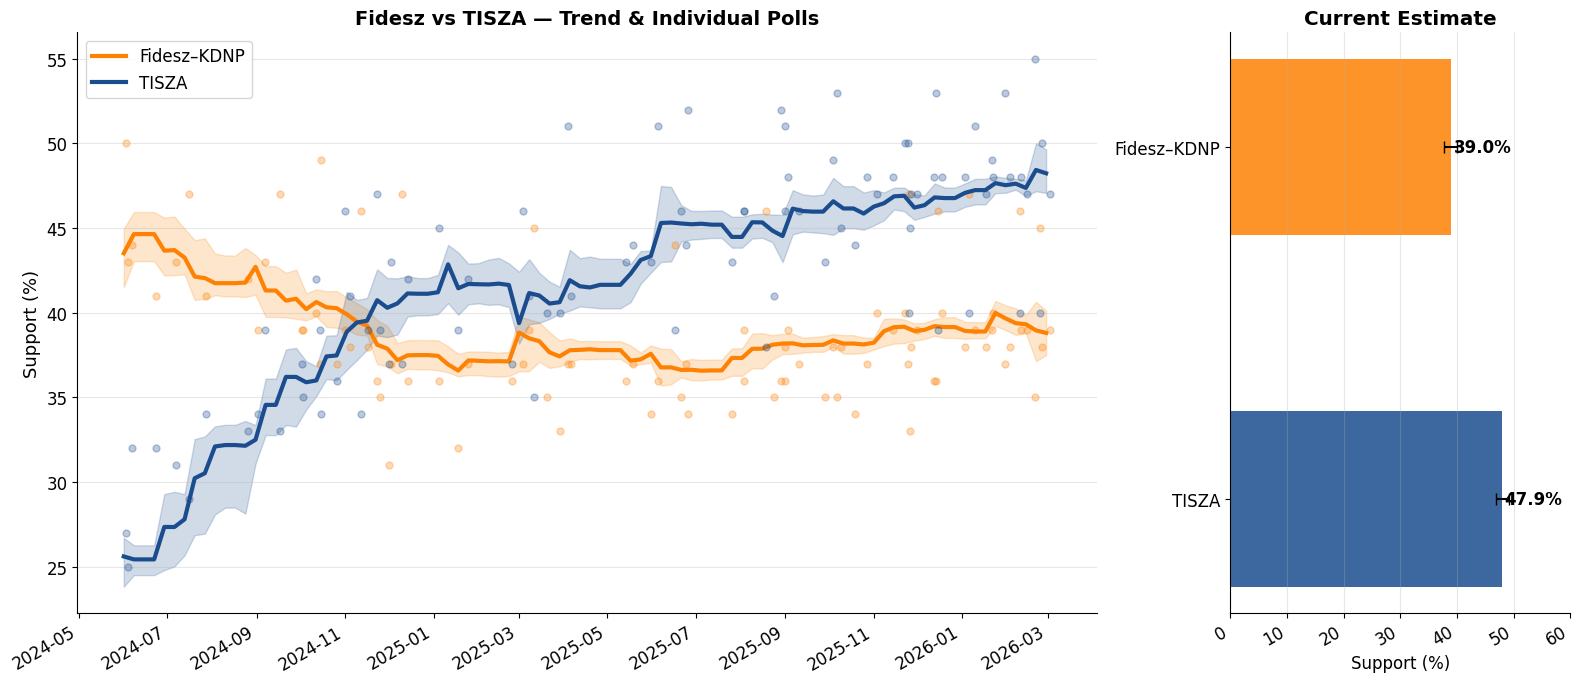

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [3, 1]})

ax = axes[0]
for party in ['Fidesz', 'TISZA']:
    td = trend_data[party]
    if not td['dates']:
        continue
    ax.fill_between(td['dates'], td['lo'], td['hi'], alpha=0.2, color=PARTY_COLORS[party])
    ax.plot(td['dates'], td['med'], color=PARTY_COLORS[party], linewidth=3,
            label=PARTY_LABELS[party])

    mask = df[party].notna() & (df['mid_date'] >= pd.Timestamp('2024-06-01'))
    ax.scatter(df.loc[mask, 'mid_date'], df.loc[mask, party],
               color=PARTY_COLORS[party], alpha=0.3, s=25, zorder=2)

ax.set_ylabel('Support (%)', fontsize=13)
ax.set_title('Fidesz vs TISZA — Trend & Individual Polls', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate()
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
est_fidesz = current_estimate['Fidesz']
est_tisza = current_estimate['TISZA']

bars = ax2.barh(
    ['TISZA', 'Fidesz–KDNP'],
    [est_tisza[1], est_fidesz[1]],
    color=[PARTY_COLORS['TISZA'], PARTY_COLORS['Fidesz']],
    height=0.5, alpha=0.85
)
ax2.errorbar(
    [est_tisza[1], est_fidesz[1]],
    ['TISZA', 'Fidesz–KDNP'],
    xerr=[[est_tisza[1]-est_tisza[0], est_fidesz[1]-est_fidesz[0]],
          [est_tisza[2]-est_tisza[1], est_fidesz[2]-est_fidesz[1]]],
    fmt='none', ecolor='black', capsize=4, linewidth=1.5
)

for bar_val, name in zip([est_tisza[1], est_fidesz[1]], ['TISZA', 'Fidesz–KDNP']):
    ax2.text(bar_val + 0.5, name, f'{bar_val:.1f}%', va='center', fontsize=12, fontweight='bold')

ax2.set_xlabel('Support (%)')
ax2.set_title('Current Estimate', fontweight='bold')
ax2.set_xlim(0, 60)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Pollster Comparison — Latest Polls

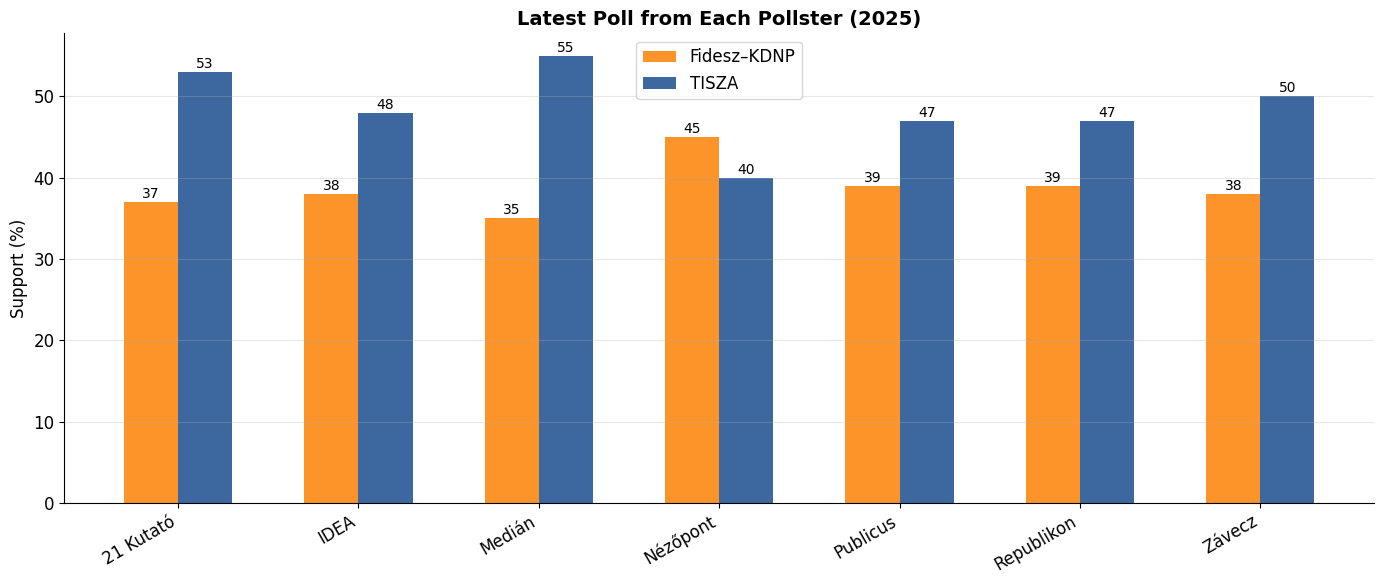

In [32]:
latest_by_pollster = (
    df[df['mid_date'] >= '2025-01-01']
    .sort_values('mid_date')
    .groupby('pollster')
    .last()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

pollster_names = latest_by_pollster['pollster'].values
x = np.arange(len(pollster_names))
width = 0.3

for i, party in enumerate(['Fidesz', 'TISZA']):
    vals = latest_by_pollster[party].values.astype(float)
    ax.bar(x + i * width, vals, width, label=PARTY_LABELS[party],
           color=PARTY_COLORS[party], alpha=0.85)
    for j, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(x[j] + i * width, v + 0.5, f'{v:.0f}', ha='center', fontsize=10)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(pollster_names, rotation=30, ha='right')
ax.set_ylabel('Support (%)')
ax.set_title('Latest Poll from Each Pollster (2025)', fontweight='bold', fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Win Probability Simulation

  WIN PROBABILITY (popular vote plurality)
  TISZA wins:           94.6%
  Fidesz–KDNP wins:      5.4%


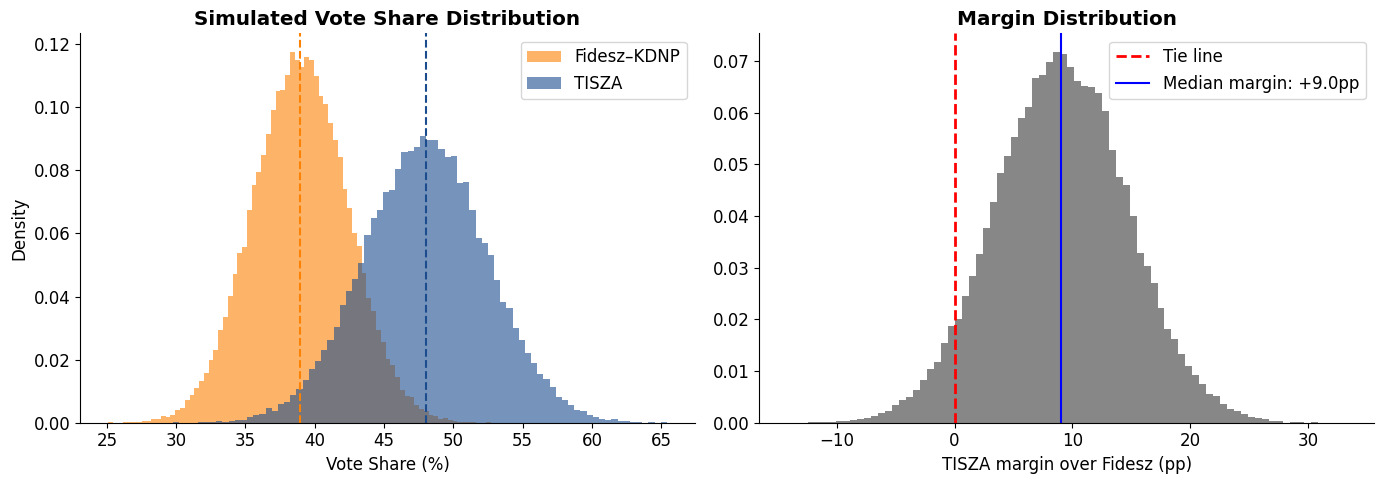

In [33]:
rng = np.random.default_rng(2026)
n_sim = 50000

recent_polls = df[df['mid_date'] >= df['mid_date'].max() - timedelta(days=60)].copy()

point_est = weighted_poll_average(df, parties, house_effects=house_effects)

poll_std = {}
for party in parties:
    vals = recent_polls[party].dropna()
    if len(vals) >= 3:
        poll_std[party] = vals.std()
    else:
        poll_std[party] = 3.0

simulations = {}
for party in parties:
    if np.isnan(point_est[party]):
        simulations[party] = np.full(n_sim, np.nan)
    else:
        simulations[party] = rng.normal(point_est[party], poll_std[party], n_sim)
        simulations[party] = np.clip(simulations[party], 0, 100)

fidesz_wins = np.nansum(simulations['Fidesz'] > simulations['TISZA'])
tisza_wins = np.nansum(simulations['TISZA'] > simulations['Fidesz'])
ties = n_sim - fidesz_wins - tisza_wins

print("=" * 50)
print("  WIN PROBABILITY (popular vote plurality)")
print("=" * 50)
print(f"  TISZA wins:         {tisza_wins/n_sim*100:>6.1f}%")
print(f"  Fidesz–KDNP wins:   {fidesz_wins/n_sim*100:>6.1f}%")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for party in ['Fidesz', 'TISZA']:
    ax.hist(simulations[party], bins=80, alpha=0.6, color=PARTY_COLORS[party],
            label=PARTY_LABELS[party], density=True)
ax.axvline(point_est['Fidesz'], color=PARTY_COLORS['Fidesz'], linestyle='--', linewidth=1.5)
ax.axvline(point_est['TISZA'], color=PARTY_COLORS['TISZA'], linestyle='--', linewidth=1.5)
ax.set_xlabel('Vote Share (%)')
ax.set_ylabel('Density')
ax.set_title('Simulated Vote Share Distribution', fontweight='bold')
ax.legend()

ax2 = axes[1]
margin = simulations['TISZA'] - simulations['Fidesz']
ax2.hist(margin, bins=80, alpha=0.7, color='#555555', density=True)
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Tie line')
ax2.axvline(np.median(margin), color='blue', linestyle='-', linewidth=1.5,
            label=f'Median margin: {np.median(margin):+.1f}pp')
ax2.set_xlabel('TISZA margin over Fidesz (pp)')
ax2.set_title('Margin Distribution', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Summary Dashboard

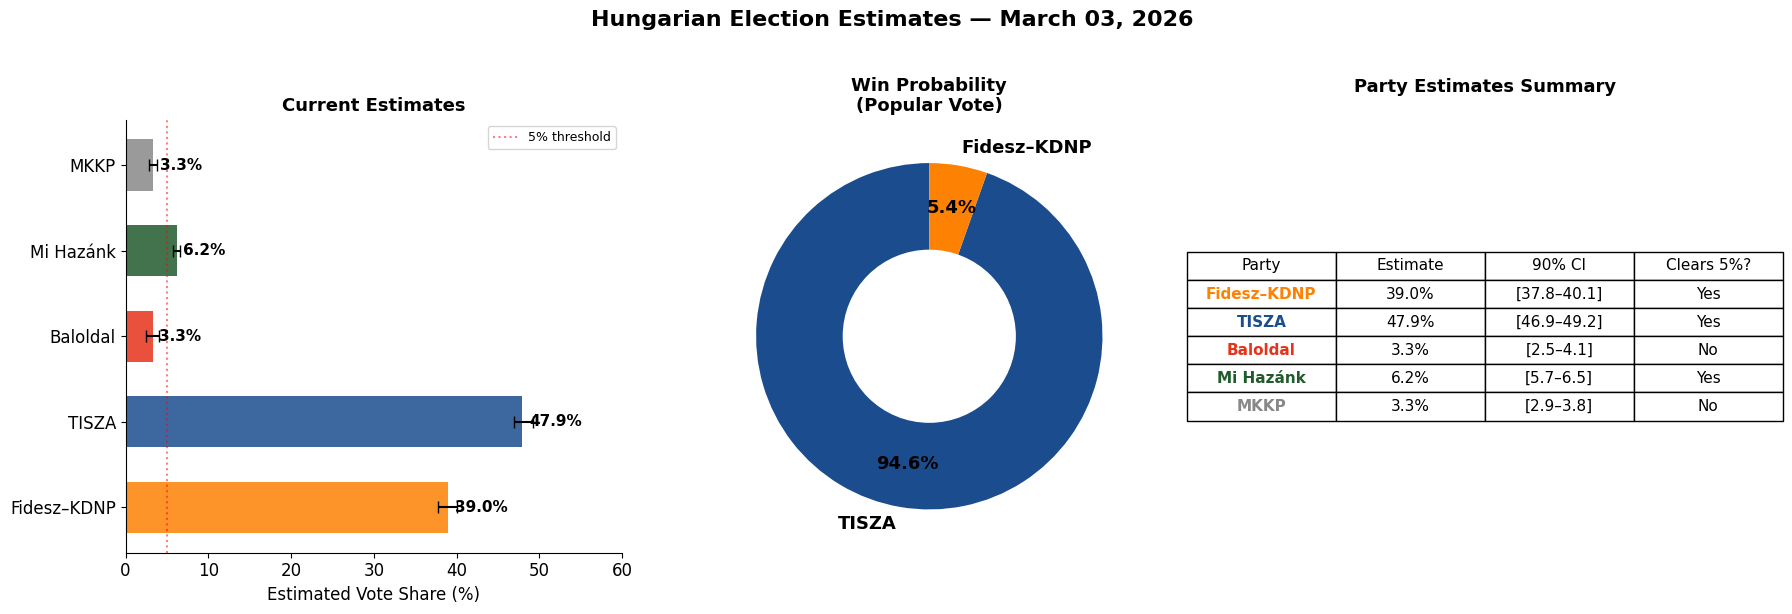

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Panel 1: Current estimates bar chart ---
ax = axes[0]
est_parties = [p for p in parties if not np.isnan(current_estimate[p][1])]
est_vals = [current_estimate[p][1] for p in est_parties]
est_lo = [current_estimate[p][1] - current_estimate[p][0] for p in est_parties]
est_hi = [current_estimate[p][2] - current_estimate[p][1] for p in est_parties]
colors = [PARTY_COLORS[p] for p in est_parties]
labels = [PARTY_LABELS[p] for p in est_parties]

bars = ax.barh(labels, est_vals, color=colors, alpha=0.85, height=0.6)
ax.errorbar(est_vals, labels, xerr=[est_lo, est_hi],
            fmt='none', ecolor='black', capsize=4, linewidth=1.5)
ax.axvline(5, color='red', linestyle=':', alpha=0.5, label='5% threshold')
for i, v in enumerate(est_vals):
    ax.text(v + 0.8, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('Estimated Vote Share (%)')
ax.set_title('Current Estimates', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0, 60)

# --- Panel 2: Win probability donut ---
ax2 = axes[1]
win_data = [tisza_wins / n_sim, fidesz_wins / n_sim]
win_labels = ['TISZA', 'Fidesz–KDNP']
win_colors = [PARTY_COLORS['TISZA'], PARTY_COLORS['Fidesz']]

wedges, texts, autotexts = ax2.pie(
    win_data, labels=win_labels, colors=win_colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75, textprops={'fontsize': 13, 'fontweight': 'bold'}
)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('Win Probability\n(Popular Vote)', fontweight='bold', fontsize=13)

# --- Panel 3: 5% threshold table ---
ax3 = axes[2]
ax3.axis('off')

table_data = []
for p in est_parties:
    lo, med, hi = current_estimate[p]
    above_threshold = "Yes" if lo > 5 else ("Likely" if med > 5 else "No")
    table_data.append([PARTY_LABELS[p], f"{med:.1f}%", f"[{lo:.1f}–{hi:.1f}]", above_threshold])

table = ax3.table(
    cellText=table_data,
    colLabels=['Party', 'Estimate', '90% CI', 'Clears 5%?'],
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for i in range(len(table_data)):
    cell = table[i + 1, 0]
    cell.set_text_props(fontweight='bold', color=colors[i])

ax3.set_title('Party Estimates Summary', fontweight='bold', fontsize=13, pad=20)

plt.suptitle(
    f'Hungarian Election Estimates — {df["mid_date"].max():%B %d, %Y}',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## 10. TISZA–Fidesz Margin Over Time

Tracking how the gap between the two leading parties has evolved.

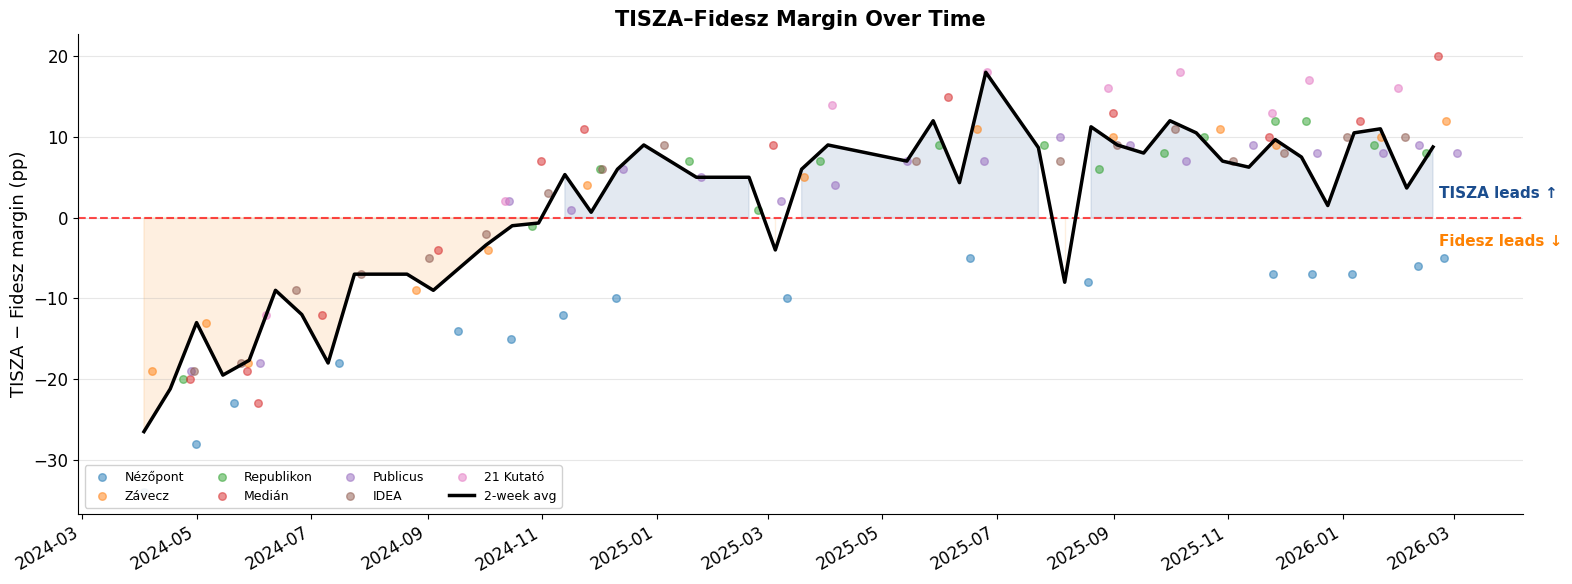

In [35]:
margin_df = df[df['TISZA'].notna() & df['Fidesz'].notna()].copy()
margin_df['margin'] = margin_df['TISZA'] - margin_df['Fidesz']

fig, ax = plt.subplots(figsize=(16, 6))

for pollster in margin_df['pollster'].unique():
    pmask = margin_df['pollster'] == pollster
    ax.scatter(margin_df.loc[pmask, 'mid_date'], margin_df.loc[pmask, 'margin'],
               alpha=0.5, s=30, label=pollster, zorder=2)

margin_roll = margin_df.set_index('mid_date')['margin'].resample('14D').mean().interpolate()
ax.plot(margin_roll.index, margin_roll.values, color='black', linewidth=2.5,
        label='2-week avg', zorder=4)

ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.fill_between(margin_roll.index, 0, margin_roll.values,
                where=margin_roll.values > 0, alpha=0.12, color=PARTY_COLORS['TISZA'])
ax.fill_between(margin_roll.index, 0, margin_roll.values,
                where=margin_roll.values < 0, alpha=0.12, color=PARTY_COLORS['Fidesz'])

ax.text(margin_roll.index[-1] + timedelta(days=3), 2, 'TISZA leads ↑',
        fontsize=11, color=PARTY_COLORS['TISZA'], fontweight='bold', va='bottom')
ax.text(margin_roll.index[-1] + timedelta(days=3), -2, 'Fidesz leads ↓',
        fontsize=11, color=PARTY_COLORS['Fidesz'], fontweight='bold', va='top')

ax.set_ylabel('TISZA − Fidesz margin (pp)', fontsize=13)
ax.set_title('TISZA–Fidesz Margin Over Time', fontsize=15, fontweight='bold')
ax.legend(loc='lower left', fontsize=9, ncol=4, framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Polling Method Comparison

Do telephone, online, and hybrid/in-person polls produce systematically different results?

C:\Users\takat\AppData\Local\Temp\ipykernel_77308\1260620130.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(bp_data, vert=False, patch_artist=True, labels=methods_sorted.index,
C:\Users\takat\AppData\Local\Temp\ipykernel_77308\1260620130.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(bp_data, vert=False, patch_artist=True, labels=methods_sorted.index,


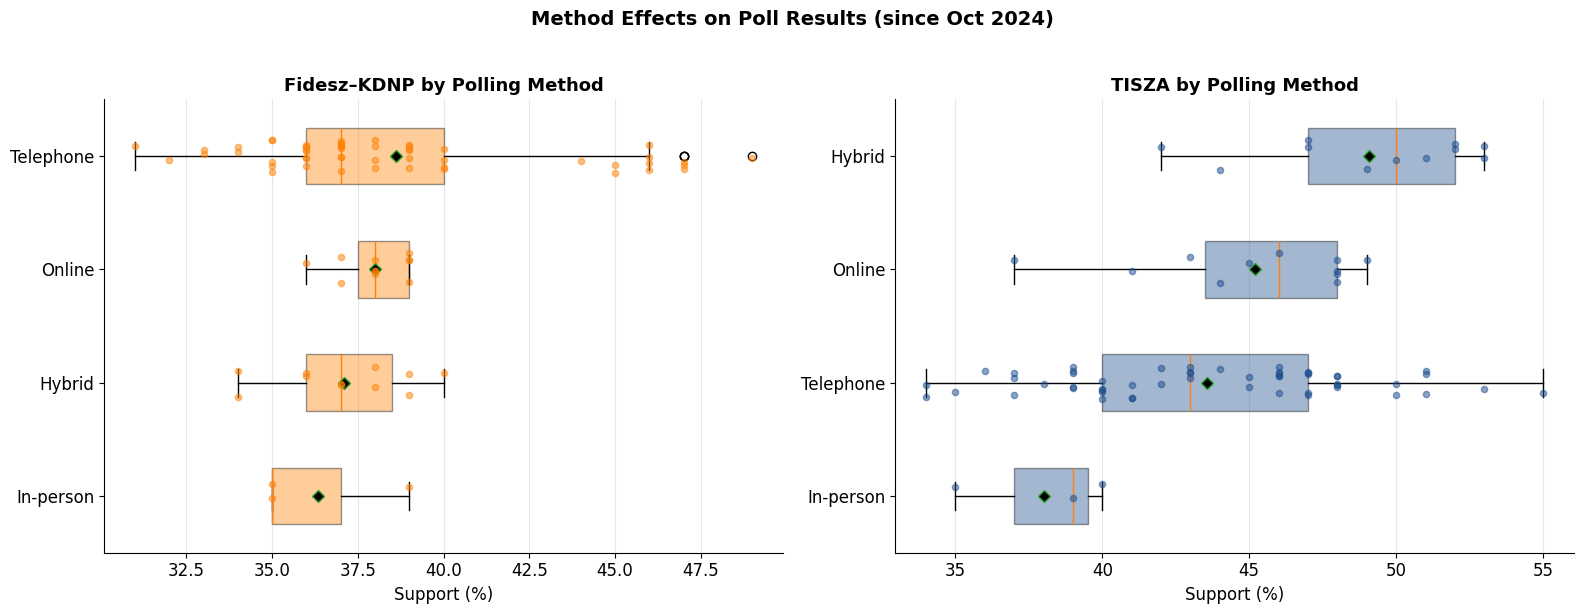

In [36]:
method_recent = df[(df['mid_date'] >= '2024-10-01') & df['TISZA'].notna()].copy()

method_map = {
    'Telefonos': 'Telephone',
    'Online': 'Online',
    'Hibrid': 'Hybrid',
    'Személyes': 'In-person',
}
method_recent['method_en'] = method_recent['method'].map(method_map).fillna(method_recent['method'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, party in enumerate(['Fidesz', 'TISZA']):
    ax = axes[i]
    methods_sorted = method_recent.groupby('method_en')[party].mean().sort_values(ascending=True)

    bp_data = [method_recent.loc[method_recent['method_en'] == m, party].dropna().values
               for m in methods_sorted.index]

    bplot = ax.boxplot(bp_data, vert=False, patch_artist=True, labels=methods_sorted.index,
                       widths=0.5, showmeans=True,
                       meanprops=dict(marker='D', markerfacecolor='black', markersize=6))

    for patch in bplot['boxes']:
        patch.set_facecolor(PARTY_COLORS[party])
        patch.set_alpha(0.4)

    for m_idx, method_name in enumerate(methods_sorted.index):
        subset = method_recent[method_recent['method_en'] == method_name]
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(subset))
        ax.scatter(subset[party].values, np.full(len(subset), m_idx + 1) + jitter,
                   alpha=0.5, s=20, color=PARTY_COLORS[party], zorder=3)

    ax.set_xlabel('Support (%)')
    ax.set_title(f'{PARTY_LABELS[party]} by Polling Method', fontweight='bold', fontsize=13)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Method Effects on Poll Results (since Oct 2024)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Polling Frequency & Coverage

When and how often each pollster publishes.

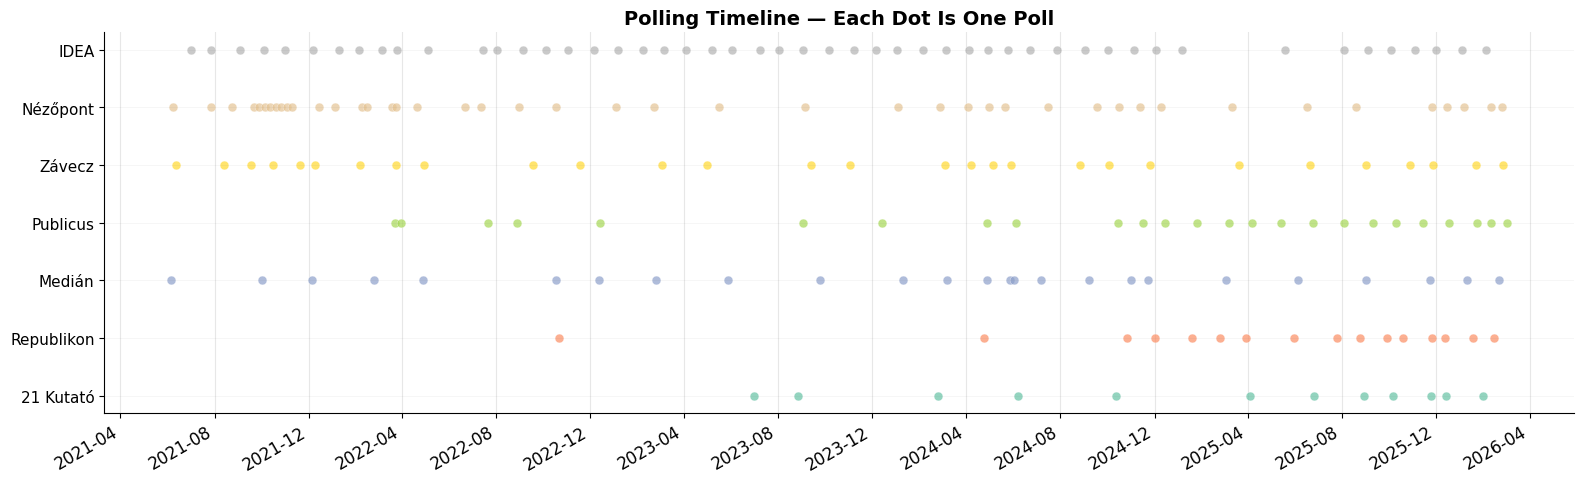

,n_polls,first,last,avg_gap_days
pollster,,,,
Publicus,13,2025-01-24 12:00:00,2026-03-03 00:00:00,33.5
Republikon,12,2025-01-18 00:00:00,2026-02-14 12:00:00,35.6
IDEA,9,2025-01-05 00:00:00,2026-02-03 00:00:00,49.2
Nézőpont,8,2025-03-11 00:00:00,2026-02-24 00:00:00,50.0
21 Kutató,7,2025-04-04 00:00:00,2026-01-30 12:00:00,50.2
Závecz,7,2025-03-20 12:00:00,2026-02-25 00:00:00,56.8
Medián,6,2025-03-03 12:00:00,2026-02-20 12:00:00,70.8


In [37]:
pollsters_ordered = (df.groupby('pollster')['mid_date'].count()
                     .sort_values(ascending=True).index.tolist())

fig, ax = plt.subplots(figsize=(16, 5))

pollster_colors = plt.cm.Set2(np.linspace(0, 1, len(pollsters_ordered)))

for i, pollster in enumerate(pollsters_ordered):
    pmask = df['pollster'] == pollster
    dates = df.loc[pmask, 'mid_date'].values
    ax.scatter(dates, [i] * len(dates), s=40, alpha=0.7,
               color=pollster_colors[i], zorder=2, edgecolors='white', linewidth=0.3)

ax.set_yticks(range(len(pollsters_ordered)))
ax.set_yticklabels(pollsters_ordered, fontsize=11)
ax.set_title('Polling Timeline — Each Dot Is One Poll', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
fig.autofmt_xdate()
ax.grid(axis='x', alpha=0.3)

for i in range(len(pollsters_ordered)):
    ax.axhline(i, color='grey', alpha=0.1, linewidth=0.5)

plt.tight_layout()
plt.show()

poll_freq = (df[df['mid_date'] >= '2025-01-01']
             .groupby('pollster')
             .agg(n_polls=('mid_date', 'count'),
                  first=('mid_date', 'min'),
                  last=('mid_date', 'max'))
             .sort_values('n_polls', ascending=False))
poll_freq['avg_gap_days'] = ((poll_freq['last'] - poll_freq['first']).dt.days / (poll_freq['n_polls'] - 1)).round(1)
poll_freq

## 13. Small Party Threshold Analysis

Probability of each smaller party clearing the 5% parliamentary threshold, based on simulation.

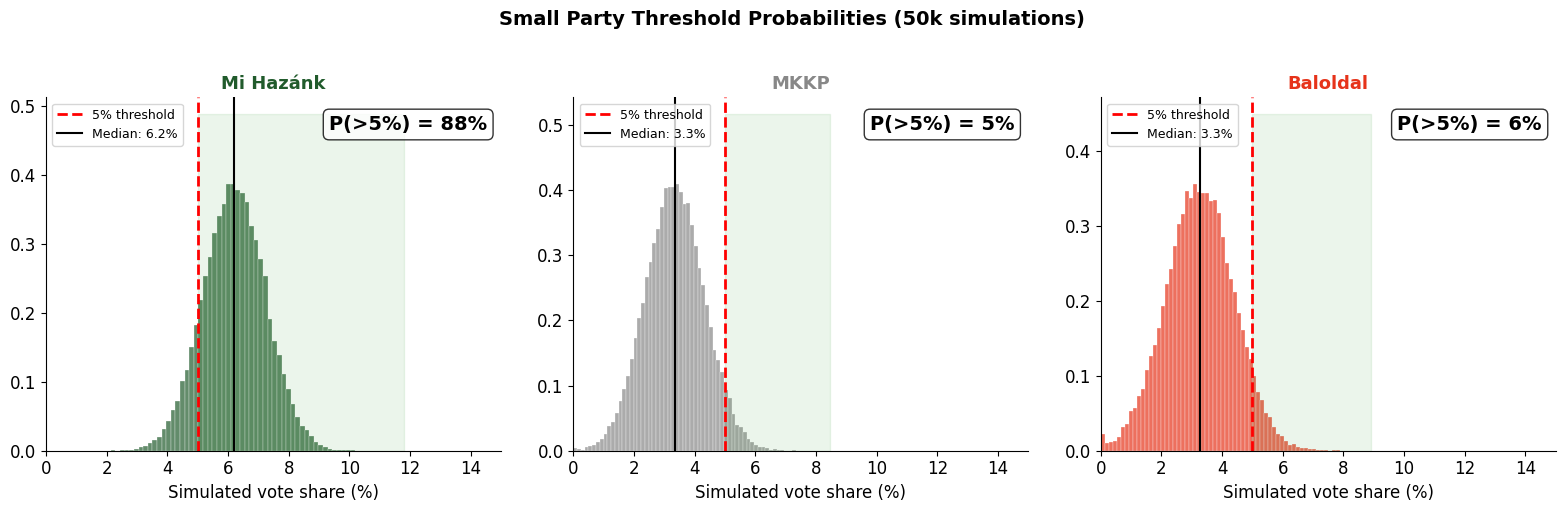

In [38]:
small_parties = ['MiHazank', 'MKKP', 'Bal']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, party in enumerate(small_parties):
    ax = axes[i]
    sims = simulations[party]
    valid = sims[~np.isnan(sims)]

    ax.hist(valid, bins=60, alpha=0.7, color=PARTY_COLORS.get(party, '#666'),
            density=True, edgecolor='white', linewidth=0.3)
    ax.axvline(5, color='red', linestyle='--', linewidth=2, label='5% threshold')
    ax.axvline(np.median(valid), color='black', linestyle='-', linewidth=1.5,
               label=f'Median: {np.median(valid):.1f}%')

    pct_above = (valid > 5).mean() * 100
    ax.fill_betweenx([0, ax.get_ylim()[1] * 1.2], 5, valid.max() + 1,
                     alpha=0.08, color='green')

    ax.set_title(f'{PARTY_LABELS[party]}', fontweight='bold', fontsize=13,
                 color=PARTY_COLORS.get(party, '#333'))
    ax.text(0.97, 0.95, f'P(>5%) = {pct_above:.0f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_xlabel('Simulated vote share (%)')
    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim(0, max(15, np.percentile(valid, 99) + 2))

plt.suptitle('Small Party Threshold Probabilities (50k simulations)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Pollster Divergence Heatmap

How much do pollsters disagree with each other? Measured as the average absolute difference between each pair of pollsters' latest overlapping polls.

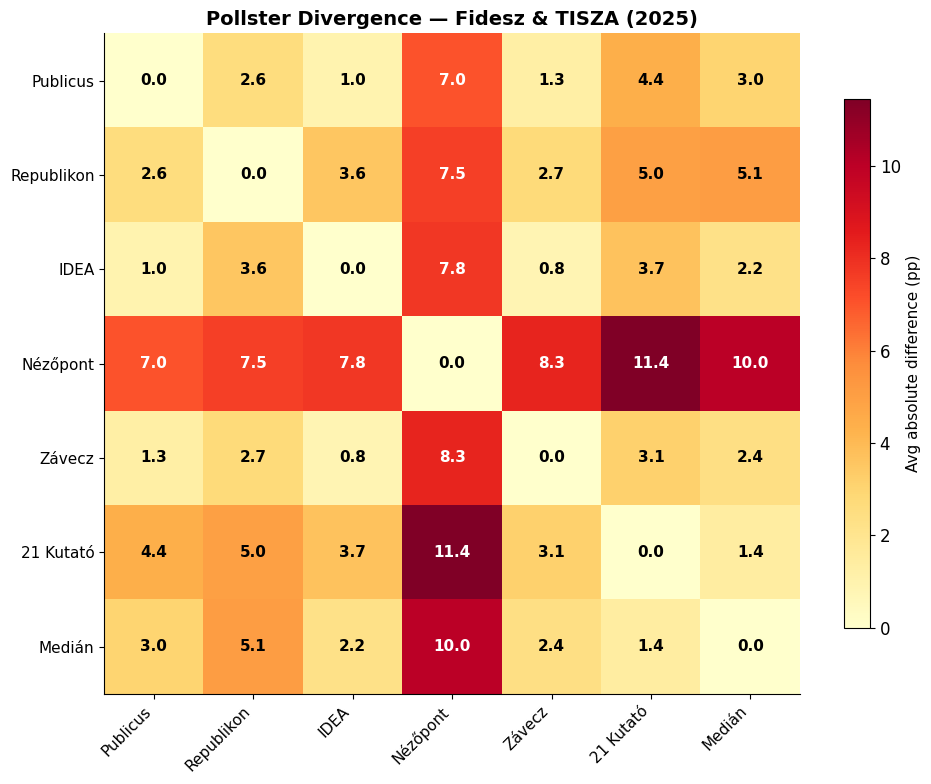

In [39]:
compare_df = df[(df['mid_date'] >= '2025-01-01') & df['TISZA'].notna()].copy()
compare_pollsters = compare_df['pollster'].value_counts()
compare_pollsters = compare_pollsters[compare_pollsters >= 2].index.tolist()

divergence = pd.DataFrame(np.nan, index=compare_pollsters, columns=compare_pollsters)

for p1 in compare_pollsters:
    for p2 in compare_pollsters:
        vals1 = compare_df[compare_df['pollster'] == p1][['Fidesz', 'TISZA']].mean()
        vals2 = compare_df[compare_df['pollster'] == p2][['Fidesz', 'TISZA']].mean()
        divergence.loc[p1, p2] = np.abs(vals1 - vals2).mean()

divergence = divergence.astype(float)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(divergence.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(compare_pollsters)))
ax.set_yticks(range(len(compare_pollsters)))
ax.set_xticklabels(compare_pollsters, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(compare_pollsters, fontsize=11)

for i in range(len(compare_pollsters)):
    for j in range(len(compare_pollsters)):
        val = divergence.values[i, j]
        color = 'white' if val > divergence.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=11,
                fontweight='bold', color=color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Avg absolute difference (pp)', fontsize=11)
ax.set_title('Pollster Divergence — Fidesz & TISZA (2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Monthly Momentum — Who's Gaining?

Month-over-month change in the weighted polling average for the two leading parties.

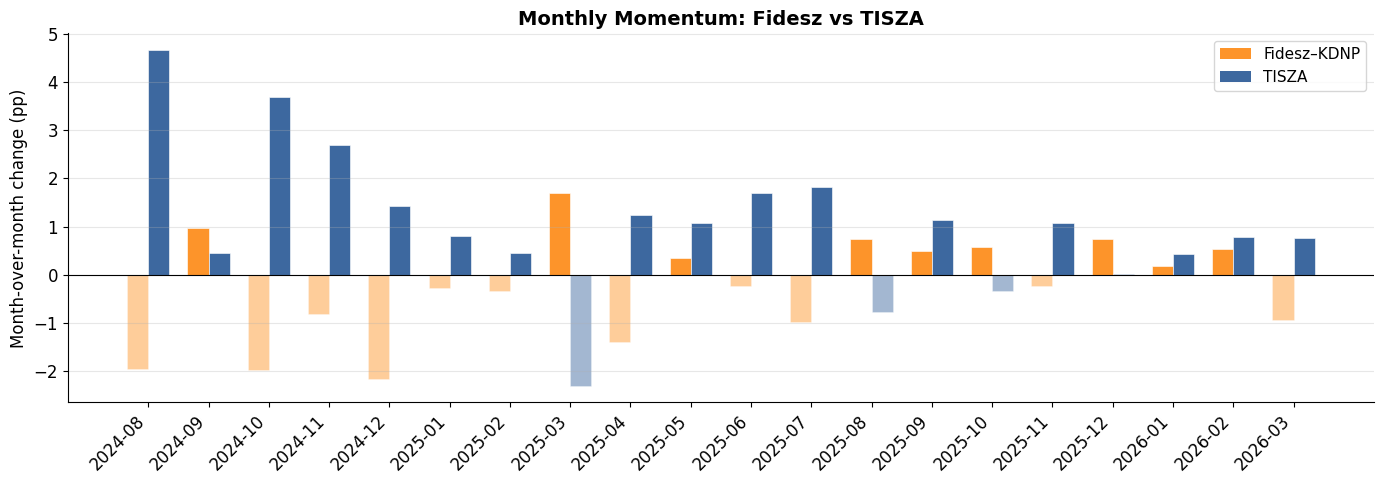

In [40]:
monthly_dates = pd.date_range('2024-07-01', df['mid_date'].max(), freq='MS')
monthly_est = {p: [] for p in ['Fidesz', 'TISZA']}
monthly_labels = []

for d in monthly_dates:
    est = weighted_poll_average(df, ['Fidesz', 'TISZA'], as_of_date=d, house_effects=house_effects)
    for p in ['Fidesz', 'TISZA']:
        monthly_est[p].append(est[p])
    monthly_labels.append(d)

momentum = {}
for p in ['Fidesz', 'TISZA']:
    arr = np.array(monthly_est[p])
    momentum[p] = np.diff(arr)

mom_dates = monthly_labels[1:]

fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(mom_dates))
width = 0.35

for i, party in enumerate(['Fidesz', 'TISZA']):
    vals = momentum[party]
    colors_bar = [PARTY_COLORS[party] if v >= 0 else PARTY_COLORS[party] for v in vals]
    alphas = [0.85 if v >= 0 else 0.4 for v in vals]
    for j, (v, c, a) in enumerate(zip(vals, colors_bar, alphas)):
        ax.bar(x[j] + i * width, v, width, color=c, alpha=a,
               edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width / 2)
ax.set_xticklabels([d.strftime('%Y-%m') for d in mom_dates], rotation=45, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Month-over-month change (pp)')
ax.set_title('Monthly Momentum: Fidesz vs TISZA', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=PARTY_COLORS['Fidesz'], alpha=0.85, label='Fidesz–KDNP'),
    Patch(facecolor=PARTY_COLORS['TISZA'], alpha=0.85, label='TISZA'),
], fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Simulated Seat Projection (Proportional List Only)

A rough proportional seat allocation from the national list (93 seats) using the d'Hondt method, based on simulated vote shares. This only covers the list component — the 106 single-member districts are not modelled here.

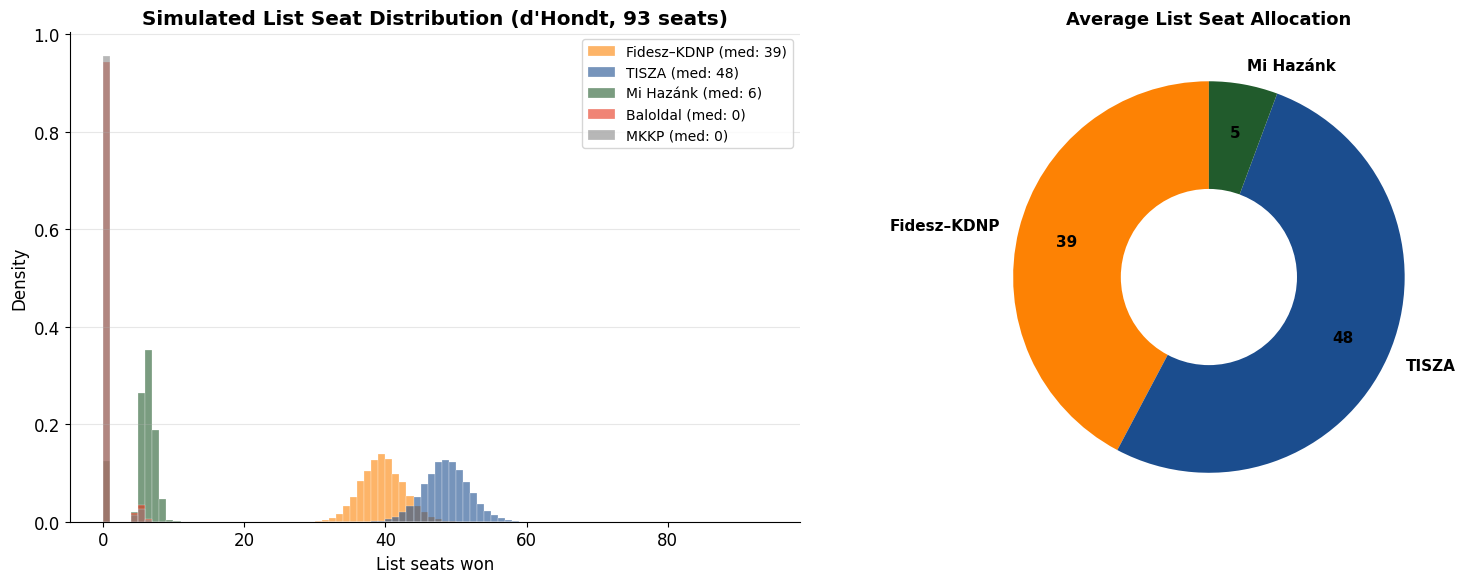


List seat estimates (93 total):
Party                  Median     Mean    5th %   95th %
--------------------------------------------------
Fidesz–KDNP               39     39.1       34       44
TISZA                     48     48.2       43       53
Mi Hazánk                  6      5.2        0        8
Baloldal                   0      0.3        0        4
MKKP                       0      0.2        0        0


In [41]:
def dhondt(votes, n_seats):
    """d'Hondt proportional seat allocation."""
    quotients = []
    for party, v in votes.items():
        for divisor in range(1, n_seats + 1):
            quotients.append((v / divisor, party))
    quotients.sort(reverse=True)
    seats = {p: 0 for p in votes}
    for _, party in quotients[:n_seats]:
        seats[party] += 1
    return seats

LIST_SEATS = 93
n_seat_sims = 10000
rng_seats = np.random.default_rng(2026)

seat_results = {p: [] for p in parties}

for _ in range(n_seat_sims):
    sim_votes = {}
    for party in parties:
        val = rng_seats.normal(point_est[party], poll_std[party])
        val = max(val, 0)
        sim_votes[party] = val

    qualifying = {p: v for p, v in sim_votes.items() if v >= 5}
    if not qualifying:
        for p in parties:
            seat_results[p].append(0)
        continue

    seats = dhondt(qualifying, LIST_SEATS)
    for p in parties:
        seat_results[p].append(seats.get(p, 0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Seat distribution histograms
ax = axes[0]
for party in ['Fidesz', 'TISZA', 'MiHazank', 'Bal', 'MKKP']:
    arr = np.array(seat_results[party])
    if arr.max() == 0:
        continue
    ax.hist(arr, bins=range(0, LIST_SEATS + 2), alpha=0.6,
            color=PARTY_COLORS[party], label=f"{PARTY_LABELS[party]} (med: {np.median(arr):.0f})",
            density=True, edgecolor='white', linewidth=0.3)
ax.set_xlabel('List seats won')
ax.set_ylabel('Density')
ax.set_title('Simulated List Seat Distribution (d\'Hondt, 93 seats)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Average seat allocation pie
ax2 = axes[1]
avg_seats = {PARTY_LABELS[p]: np.mean(seat_results[p]) for p in parties if np.mean(seat_results[p]) > 0.5}
seat_colors = [PARTY_COLORS[p] for p in parties if np.mean(seat_results[p]) > 0.5]

wedges, texts, autotexts = ax2.pie(
    avg_seats.values(), labels=avg_seats.keys(), colors=seat_colors,
    autopct=lambda pct: f'{pct * LIST_SEATS / 100:.0f}',
    startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
    pctdistance=0.75
)
centre_circle = plt.Circle((0, 0), 0.45, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('Average List Seat Allocation', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print("\nList seat estimates (93 total):")
print(f"{'Party':<20} {'Median':>8} {'Mean':>8} {'5th %':>8} {'95th %':>8}")
print("-" * 50)
for p in ['Fidesz', 'TISZA', 'MiHazank', 'Bal', 'MKKP']:
    arr = np.array(seat_results[p])
    print(f"{PARTY_LABELS[p]:<20} {np.median(arr):>7.0f}  {np.mean(arr):>7.1f}  {np.percentile(arr, 5):>7.0f}  {np.percentile(arr, 95):>7.0f}")